# LangGraph migration spike

Wrap the existing pipeline in a LangGraph. Stages 1–2 stay linear wrappers around `app/` functions. **Stage 3** uses `backend/lg_spike/stage3.py` + `search.py` (one parallel worker per `search_backends[]` entry). `app/` is left unchanged — including `app.job_discovery.tools`.

```text
START → prepare_resume → stage1 → stage2 → stage3 → END
                                         └─ plan queries
                                              → [Send] run_engine_search × N engines
                                              → reduce/fit → synthesize
```

## Goals

1. Define `PipelineState` (inputs + what `/v1/pipeline` returns).
2. Thin node wrappers around `prepare_resume`, `run_stage1`, `run_stage2`, and `stage3.run_stage3`.
3. `graph.invoke({...})` returns the same shape as today’s `PipelineResult`.

**Not needed for this spike:** FastAPI app/middleware, Sentry, OpenTelemetry, or a full `main.py` import dump.

Out of scope: LangChain chat models, ReAct agents, checkpointers, human-in-the-loop. Do not edit `app/pipeline.py` or `app/job_discovery/tools.py`.

See `backend/lg_spike/langgraph-migration.md`. Requires `langgraph` in the backend `.venv` (`pip install langgraph`).


## Notebook path setup

The API runs with cwd `backend/`, so `import app...` works. This notebook often starts in `backend/lg_spike/`, which causes `ModuleNotFoundError: No module named 'app'`.

Put `backend/` on `sys.path` so pipeline imports resolve.

In [61]:
import sys
from pathlib import Path

backend_root = Path.cwd().resolve()
if backend_root.name == "lg_spike":
    backend_root = backend_root.parent
sys.path.insert(0, str(backend_root))
sys.path.insert(0, str(backend_root / "lg_spike"))


## Pipeline imports

Only what the graph nodes need. Importing `app.core.config` loads `backend/config.toml` (same as the API).

In [ ]:
# pyright: reportUnusedImport=false
# ruff: noqa: F401

from app.core.config import config  # noqa: F401 — loads config.toml
from app.core.input_safety import prepare_resume
from app.pipeline import run_stage1
from app.role_family_plan import run_stage2
from stage3 import run_stage3


## State

Shared `PipelineState` for the graph (`resume` required on invoke). Nodes return `PipelineStateUpdate` (`total=False`) — partial patches LangGraph merges into state.


In [63]:
from typing_extensions import NotRequired, TypedDict

from app.core.json_types import JsonObject
from app.core.models import Constraints


class PipelineState(TypedDict):
    resume: str
    constraints: NotRequired[Constraints | None]
    aptitude_profile: NotRequired[JsonObject]
    role_family_plan: NotRequired[JsonObject]
    occupation_matches: NotRequired[list[JsonObject]]
    verified_matches: NotRequired[JsonObject]


# Partial updates returned by graph nodes (LangGraph merges these into state).
class PipelineStateUpdate(TypedDict, total=False):
    resume: str
    constraints: Constraints | None
    aptitude_profile: JsonObject
    role_family_plan: JsonObject
    occupation_matches: list[JsonObject]
    verified_matches: JsonObject


## Nodes

Thin wrappers: read state → call existing functions → return partial state updates. basedpyright may flag names from prior cells; runtime is fine if you ran those cells first.

In [64]:
# pyright: reportUndefinedVariable=false
# pyright: reportUnknownVariableType=false
# pyright: reportUnknownParameterType=false
# pyright: reportUnknownArgumentType=false
# pyright: reportUnknownMemberType=false

def node_prepare_resume(state: PipelineState) -> PipelineStateUpdate:
    return {"resume": prepare_resume(state["resume"])}


def node_stage1(state: PipelineState) -> PipelineStateUpdate:
    return {"aptitude_profile": run_stage1(state["resume"])}


def node_stage2(state: PipelineState) -> PipelineStateUpdate:
    profile = state.get("aptitude_profile")
    if profile is None:
        raise KeyError("aptitude_profile")
    result = run_stage2(profile)
    return {
        "role_family_plan": result.role_family_plan,
        "occupation_matches": [m.to_json() for m in result.occupation_matches],
    }


def node_stage3(state: PipelineState) -> PipelineStateUpdate:
    profile = state.get("aptitude_profile")
    if profile is None:
        raise KeyError("aptitude_profile")
    return {
        "verified_matches": run_stage3(
            profile,
            state.get("constraints"),
            role_family_plan=state.get("role_family_plan"),
        )
    }


## Graph

Linear `StateGraph` matching `run_pipeline`. After `compile()`, render the graph like the LangGraph Academy notebooks (`draw_mermaid_png`).


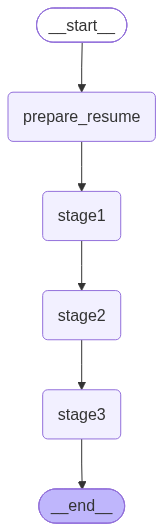

In [65]:
# pyright: reportUndefinedVariable=false
# pyright: reportUnusedCallResult=false
# pyright: reportUnknownMemberType=false
# pyright: reportUnknownVariableType=false
# pyright: reportUnknownArgumentType=false

from IPython.display import Image
from langgraph.graph import END, START, StateGraph  # pyright: ignore[reportMissingTypeStubs]

builder = StateGraph(PipelineState)
builder.add_node("prepare_resume", node_prepare_resume)
builder.add_node("stage1", node_stage1)
builder.add_node("stage2", node_stage2)
builder.add_node("stage3", node_stage3)

builder.add_edge(START, "prepare_resume")
builder.add_edge("prepare_resume", "stage1")
builder.add_edge("stage1", "stage2")
builder.add_edge("stage2", "stage3")
builder.add_edge("stage3", END)
graph = builder.compile()

Image(graph.get_graph().draw_mermaid_png())


## Invoke

Run the compiled graph on a fixture resume from `fixtures/sample-resumes/`. This is a **live** pipeline call (HF + discovery + DB) — needs `config.toml` and network.


In [66]:
# pyright: reportUndefinedVariable=false
# pyright: reportUnknownMemberType=false
# pyright: reportUnknownVariableType=false
# pyright: reportUnknownArgumentType=false

import json
from pathlib import Path

_repo_root = Path.cwd().resolve()
if _repo_root.name == "lg_spike":
    _repo_root = _repo_root.parent.parent
elif _repo_root.name == "backend":
    _repo_root = _repo_root.parent

# Sample resumes under fixtures/sample-resumes/ (swap the filename below):
#   career-changer-mixed-stack.txt
#   senior-backend-engineer.txt
#   marketing-operations-lead.txt
#   pre-college-retail-service.txt
#   long-unemployment-gap-admin-coordinator.txt
#   prompt-injection-ignore-instructions.txt  # expect input-safety 400
resume_path = (
    _repo_root / "fixtures" / "sample-resumes" / "career-changer-mixed-stack.txt"
)
resume = resume_path.read_text(encoding="utf-8")
print(f"Loaded {resume_path.name} ({len(resume)} chars)")

result = graph.invoke({"resume": resume, "constraints": None})
print(sorted(result.keys()))
print(json.dumps(result, indent=2, default=str))


Loaded career-changer-mixed-stack.txt (1186 chars)
['aptitude_profile', 'constraints', 'occupation_matches', 'resume', 'role_family_plan', 'verified_matches']
{
  "resume": ", OR | alex.morgan@email.example |\n\nSUMMARY\nFull-stack developer with 8 years building web applications across legacy modernization and greenfield products. Comfortable owning ambiguous technical problems from discovery through deployment.\n\nEXPERIENCE\n\nSoftware Engineer \u2014 Riverbend Logistics (2021\u2013Present)\n- Migrated customer portal from ColdFusion to Django + Vue; reduced page load time 40%\n- Built internal APIs integrating warehouse scanners with backends\n- Mentored two junior developers on code review and testing practices\n\nWeb Developer \u2014 CivicWorks Nonprofit (2017\u20132021)\n- Delivered donation and volunteer scheduling tools under tight budgets and shifting requirements\n- Introduced CI/CD and basic observability (logging, error alerts) where none existed\n\nJunior Developer \u2014